In [347]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap 
#import janitor
import warnings
warnings.filterwarnings('ignore')

In [348]:
df = pd.read_csv('datasets/test.csv')

In [349]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [351]:
df.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
49995,0x25fe5,CUS_0x8600,December,Sarah McBridec,4975,031-35-0942,Architect,20002.88,1929.906667,10,...,12.0,_,3571.7,34.780553,NaN,Yes,60.964772,146.48632477751087,Low_spent_Small_value_payments,275.53956951573343
49996,0x25fee,CUS_0x942c,September,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,7.0,Good,502.38,27.758522,31 Years and 11 Months,NM,35.104023,181.44299902757518,Low_spent_Small_value_payments,409.39456169535066
49997,0x25fef,CUS_0x942c,October,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,7.0,Good,502.38,36.858542,32 Years and 0 Months,No,35.104023,__10000__,Low_spent_Large_value_payments,349.7263321025098
49998,0x25ff0,CUS_0x942c,November,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,7.0,Good,502.38,39.139840,32 Years and 1 Months,No,35.104023,97.59857973344877,High_spent_Small_value_payments,463.23898098947717
49999,0x25ff1,CUS_0x942c,December,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,7.0,_,502.38,34.108530,32 Years and 2 Months,No,35.104023,220.45787812168732,Low_spent_Medium_value_payments,360.37968260123847


In [352]:
df.dtypes

ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
dtype: object

In [354]:
df.nunique()

ID                          50000
Customer_ID                 12500
Month                           4
Name                        10139
Age                           976
SSN                         12501
Occupation                     16
Annual_Income               16121
Monthly_Inhand_Salary       12793
Num_Bank_Accounts             540
Num_Credit_Card               819
Interest_Rate                 945
Num_of_Loan                   263
Type_of_Loan                 6260
Delay_from_due_date            73
Num_of_Delayed_Payment        443
Changed_Credit_Limit         3927
Num_Credit_Inquiries          750
Credit_Mix                      4
Outstanding_Debt            12685
Credit_Utilization_Ratio    50000
Credit_History_Age            399
Payment_of_Min_Amount           3
Total_EMI_per_month         13144
Amount_invested_monthly     45450
Payment_Behaviour               7
Monthly_Balance             49433
dtype: int64

In [355]:
df.shape

(50000, 27)

In [356]:
df.isnull().sum()

ID                             0
Customer_ID                    0
Month                          0
Name                        5015
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7498
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                5704
Delay_from_due_date            0
Num_of_Delayed_Payment      3498
Changed_Credit_Limit           0
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4470
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2271
Payment_Behaviour              0
Monthly_Balance              562
dtype: int64

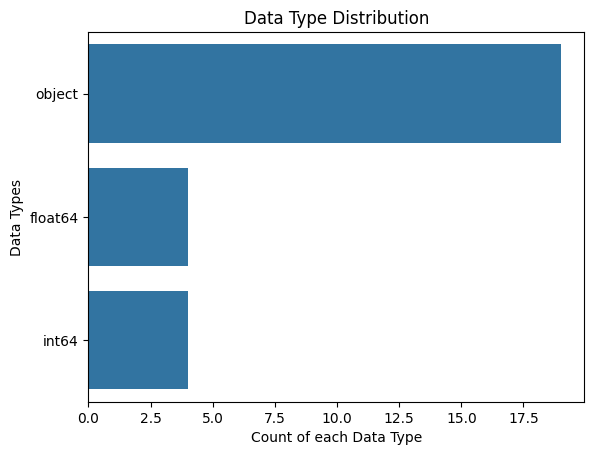

In [357]:
sns.countplot(y=df.dtypes, data=df)
plt.title('Data Type Distribution')
plt.xlabel('Count of each Data Type')
plt.ylabel('Data Types')
plt.show()

In [358]:
df.duplicated().sum()

np.int64(0)

In [359]:
df.dropna(axis=0, inplace=True)

In [360]:
df.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

In [361]:
df.shape

(26459, 27)

In [362]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

In [363]:
df = df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Type_of_Loan', 'Occupation'])

df.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,23,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,24,19114.12,1824.843333,3,4,3,4,3,9,13.27,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
4,28,34847.84,3037.986667,2,4,6,1,3,1,5.42,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923
5,28,34847.84,3037.986667,2,4,6,1,3,3,5.42,5.0,Good,605.03,30.116600,27 Years and 4 Months,No,18.816215,251.62736875017606,Low_spent_Large_value_payments,303.3550833433617
7,28,34847.84,3037.986667,2,4,6,1,3,2_,7.42,5.0,_,605.03,33.875167,27 Years and 6 Months,No,18.816215,153.53448761392985,!@9#%8,421.44796447960783


In [364]:
df.shape

(26459, 20)

In [365]:
df.dtypes

Age                          object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
dtype: object

In [366]:
strip_columns = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_History_Age', 'Amount_invested_monthly', 'Monthly_Balance']

In [367]:
df[strip_columns] = df[strip_columns].replace(r'[^0-9.]', '', regex=True)

In [368]:
obj_columns = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_History_Age', 'Amount_invested_monthly', 'Monthly_Balance']

df[obj_columns] = df[obj_columns].apply(pd.to_numeric, errors='coerce')

In [369]:
df.isna().sum()

Age                           0
Annual_Income                 0
Monthly_Inhand_Salary         0
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Num_of_Loan                   0
Delay_from_due_date           0
Num_of_Delayed_Payment        0
Changed_Credit_Limit        577
Num_Credit_Inquiries          0
Credit_Mix                    0
Outstanding_Debt              0
Credit_Utilization_Ratio      0
Credit_History_Age            0
Payment_of_Min_Amount         0
Total_EMI_per_month           0
Amount_invested_monthly       0
Payment_Behaviour             0
Monthly_Balance               0
dtype: int64

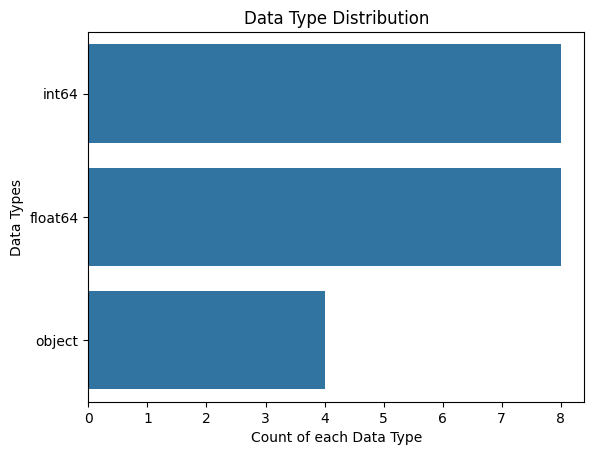

In [370]:
sns.countplot(y=df.dtypes, data=df)
plt.title('Data Type Distribution')
plt.xlabel('Count of each Data Type')
plt.ylabel('Data Types')
plt.show()

In [371]:
df.Credit_Mix.unique()

array(['Good', '_', 'Standard', 'Bad'], dtype=object)

In [372]:
df.Payment_of_Min_Amount.unique()

array(['No', 'NM', 'Yes'], dtype=object)

In [373]:
df.dtypes

Age                           int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                   int64
Delay_from_due_date           int64
Num_of_Delayed_Payment        int64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age            int64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
dtype: object

In [374]:
df.Payment_Behaviour.unique()

array(['Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'High_spent_Large_value_payments',
       'Low_spent_Large_value_payments', '!@9#%8',
       'Low_spent_Medium_value_payments',
       'High_spent_Small_value_payments'], dtype=object)

In [375]:
df = df[df.Payment_Behaviour != "!@9#%8"]

In [376]:
df.Payment_Behaviour.unique()

array(['Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'High_spent_Large_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'High_spent_Small_value_payments'], dtype=object)

In [377]:
df.shape

(24423, 20)

In [378]:
df.Credit_Mix.unique()

array(['Good', '_', 'Standard', 'Bad'], dtype=object)

In [379]:
df.Credit_Mix.value_counts()

Credit_Mix
Standard    9005
Good        5321
Bad         5265
_           4832
Name: count, dtype: int64

In [380]:
df = df[df.Credit_Mix != "_"]

In [381]:
df.Credit_Mix.value_counts()

Credit_Mix
Standard    9005
Good        5321
Bad         5265
Name: count, dtype: int64

In [382]:
df.shape

(19591, 20)

In [383]:
df.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,23,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022.0,Good,809.98,35.030402,229,No,49.574949,236.642682,Low_spent_Small_value_payments,186.266702
1,24,19114.12,1824.843333,3,4,3,4,3,9,13.27,4.0,Good,809.98,33.053114,2210,No,49.574949,21.465380,High_spent_Medium_value_payments,361.444004
4,28,34847.84,3037.986667,2,4,6,1,3,1,5.42,5.0,Good,605.03,25.926822,273,No,18.816215,39.684018,High_spent_Large_value_payments,485.298434
5,28,34847.84,3037.986667,2,4,6,1,3,3,5.42,5.0,Good,605.03,30.116600,274,No,18.816215,251.627369,Low_spent_Large_value_payments,303.355083
9,35,143162.64,12187.220000,1,5,8,3,6,3,2.10,3.0,Good,1303.01,35.685836,186,No,246.992319,453.615131,Low_spent_Large_value_payments,788.114550


In [384]:
df.Payment_of_Min_Amount.unique()

array(['No', 'NM', 'Yes'], dtype=object)

In [385]:
df.Payment_of_Min_Amount.value_counts()

Payment_of_Min_Amount
Yes    10968
No      6272
NM      2351
Name: count, dtype: int64

In [386]:
df = df[df.Payment_of_Min_Amount != "NM"]

In [387]:
df.Payment_of_Min_Amount.value_counts()

Payment_of_Min_Amount
Yes    10968
No      6272
Name: count, dtype: int64

In [388]:
df.shape

(17240, 20)

In [390]:
df.Changed_Credit_Limit.value_counts()

Changed_Credit_Limit
11.32    26
11.50    25
8.34     25
10.64    24
8.22     23
         ..
17.74     1
5.79      1
26.87     1
34.21     1
1.78      1
Name: count, Length: 2949, dtype: int64

In [391]:
df.isnull().sum()

Age                           0
Annual_Income                 0
Monthly_Inhand_Salary         0
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Num_of_Loan                   0
Delay_from_due_date           0
Num_of_Delayed_Payment        0
Changed_Credit_Limit        382
Num_Credit_Inquiries          0
Credit_Mix                    0
Outstanding_Debt              0
Credit_Utilization_Ratio      0
Credit_History_Age            0
Payment_of_Min_Amount         0
Total_EMI_per_month           0
Amount_invested_monthly       0
Payment_Behaviour             0
Monthly_Balance               0
dtype: int64

In [392]:
df.dropna(axis=0, inplace=True)

In [393]:
df.isnull().sum()

Age                         0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

In [394]:
df.shape

(16858, 20)

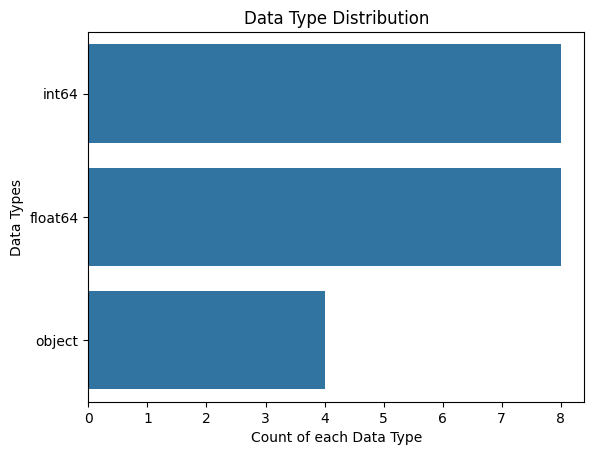

In [395]:
sns.countplot(y=df.dtypes, data=df)
plt.title('Data Type Distribution')
plt.xlabel('Count of each Data Type')
plt.ylabel('Data Types')
plt.show()

In [396]:
df.head(10)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,23,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022.0,Good,809.98,35.030402,229,No,49.574949,236.642682,Low_spent_Small_value_payments,186.266702
1,24,19114.12,1824.843333,3,4,3,4,3,9,13.27,4.0,Good,809.98,33.053114,2210,No,49.574949,21.465380,High_spent_Medium_value_payments,361.444004
4,28,34847.84,3037.986667,2,4,6,1,3,1,5.42,5.0,Good,605.03,25.926822,273,No,18.816215,39.684018,High_spent_Large_value_payments,485.298434
5,28,34847.84,3037.986667,2,4,6,1,3,3,5.42,5.0,Good,605.03,30.116600,274,No,18.816215,251.627369,Low_spent_Large_value_payments,303.355083
9,35,143162.64,12187.220000,1,5,8,3,6,3,2.10,3.0,Good,1303.01,35.685836,186,No,246.992319,453.615131,Low_spent_Large_value_payments,788.114550
12,55,30689.89,2612.490833,2,5,4,1,5,6,1.99,4.0,Good,632.46,39.377219,1711,No,16.415452,69.107006,High_spent_Medium_value_payments,425.726626
14,55,30689.89,2612.490833,2,5,4,1,5,6,1.99,4.0,Good,632.46,36.824468,181,No,16.415452,191.886244,Low_spent_Medium_value_payments,332.947388
15,55,4148862.00,2612.490833,2,5,4,1,6,6,1.99,7.0,Good,632.46,35.579265,182,No,16.415452,233.933417,Low_spent_Small_value_payments,300.900215
25,34,131313.40,10469.207759,0,1,8,2,0,2,9.34,4.0,Good,352.16,31.025571,314,No,911.220179,966.074336,Low_spent_Large_value_payments,290.559392
37,45,31370.80,2825.233333,1,6,12,2,2,3,5.76,5.0,Good,421.43,33.854096,272,No,46.616129,109.420763,High_spent_Medium_value_payments,376.486442


In [398]:
df.dtypes

Age                           int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                   int64
Delay_from_due_date           int64
Num_of_Delayed_Payment        int64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age            int64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
dtype: object

In [399]:
df.tail(10)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
49966,39,15319.65,1460.637500,6,7,15,4,53,16,17.13,6.0,Bad,1453.61,25.497671,117,Yes,28.182033,28.514703,High_spent_Large_value_payments,329.367014
49976,21,38321.39,3106.647859,4,4,3,4,11,7,1.59,6.0,Good,678.57,29.004432,177,No,362.072453,79.991128,High_spent_Large_value_payments,381.182642
49981,19,42903.79,3468.315833,1727,4,6,1,14,2,5.10,1.0,Good,1079.48,27.122224,2810,No,34.975457,134.078087,High_spent_Medium_value_payments,427.778040
49988,50,37188.10,3097.008333,1,4,5261,3,7,12,9.38,3.0,Good,620.64,32.740865,305,No,84.205949,165.115322,Low_spent_Small_value_payments,350.379562
49989,50,37188.10,3097.008333,1,4,2658,3,7,12,5.38,3.0,Good,620.64,23.986021,306,No,84.205949,10000.000000,Low_spent_Large_value_payments,270.754039
49990,50,37188.10,3097.008333,1,4,4252,3,7,12,5.38,3.0,Good,620.64,25.708414,307,No,84.205949,183.365628,Low_spent_Large_value_payments,312.129256
49992,29,20002.88,1929.906667,10,8,29,5,33,25,18.31,9.0,Bad,3571.7,32.391288,64,Yes,60.964772,107.210742,Low_spent_Small_value_payments,314.815153
49993,29,20002.88,1929.906667,10,8,29,5,33,25,18.31,12.0,Bad,3571.7,37.528511,65,Yes,60.964772,71.794421,Low_spent_Small_value_payments,350.231473
49994,29,20002.88,1929.906667,10,8,29,5,33,22,18.31,12.0,Bad,3571.7,27.027812,66,Yes,60.964772,50.846847,High_spent_Small_value_payments,341.179047
49997,25,39628.99,3359.415833,4,6,7,2,23,5,13.50,7.0,Good,502.38,36.858542,320,No,35.104023,10000.000000,Low_spent_Large_value_payments,349.726332
